<a href="https://colab.research.google.com/github/7REVOLUTiOn/UPSIS/blob/main/%D0%A3%D0%9F%D0%98%D0%A1_%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%966_%D0%A0%D0%B0%D0%B7%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_UML_%D0%B4%D0%B8%D0%B0%D0%B3%D1%80%D0%B0%D0%BC%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №6. Разработка UML-диаграмм для проектирования информационной системы**

# UML-ДИАГРАММЫ ДЛЯ ПРОЕКТИРОВАНИЯ ИНФОРМАЦИОННОЙ СИСТЕМЫ
Веб-сервис монокулярной оценки глубины и генерации 3D-моделей для 3D-печати

## 1. ДИАГРАММА ВАРИАНТОВ ИСПОЛЬЗОВАНИЯ (USE CASE DIAGRAM)

### 1.1. Акторы системы

| Актор | Описание | Технические навыки |
|-------|----------|-------------------|
| **Пользователь** | Исследователь/студент, использующий сервис для получения 3D-моделей из изображений | Средний (веб-браузер, базовые знания 3D) |
| **Администратор** | Разработчик, управляющий инфраструктурой и моделями | Высокий (DevOps, ML, backend) |
| **ML-сервис** | Внешний компонент для выполнения инференса моделей глубины | Системный актор |
| **Валидатор STL** | Внешний компонент для проверки геометрии на соответствие требованиям 3D-печати | Системный актор |

### 1.2. Варианты использования





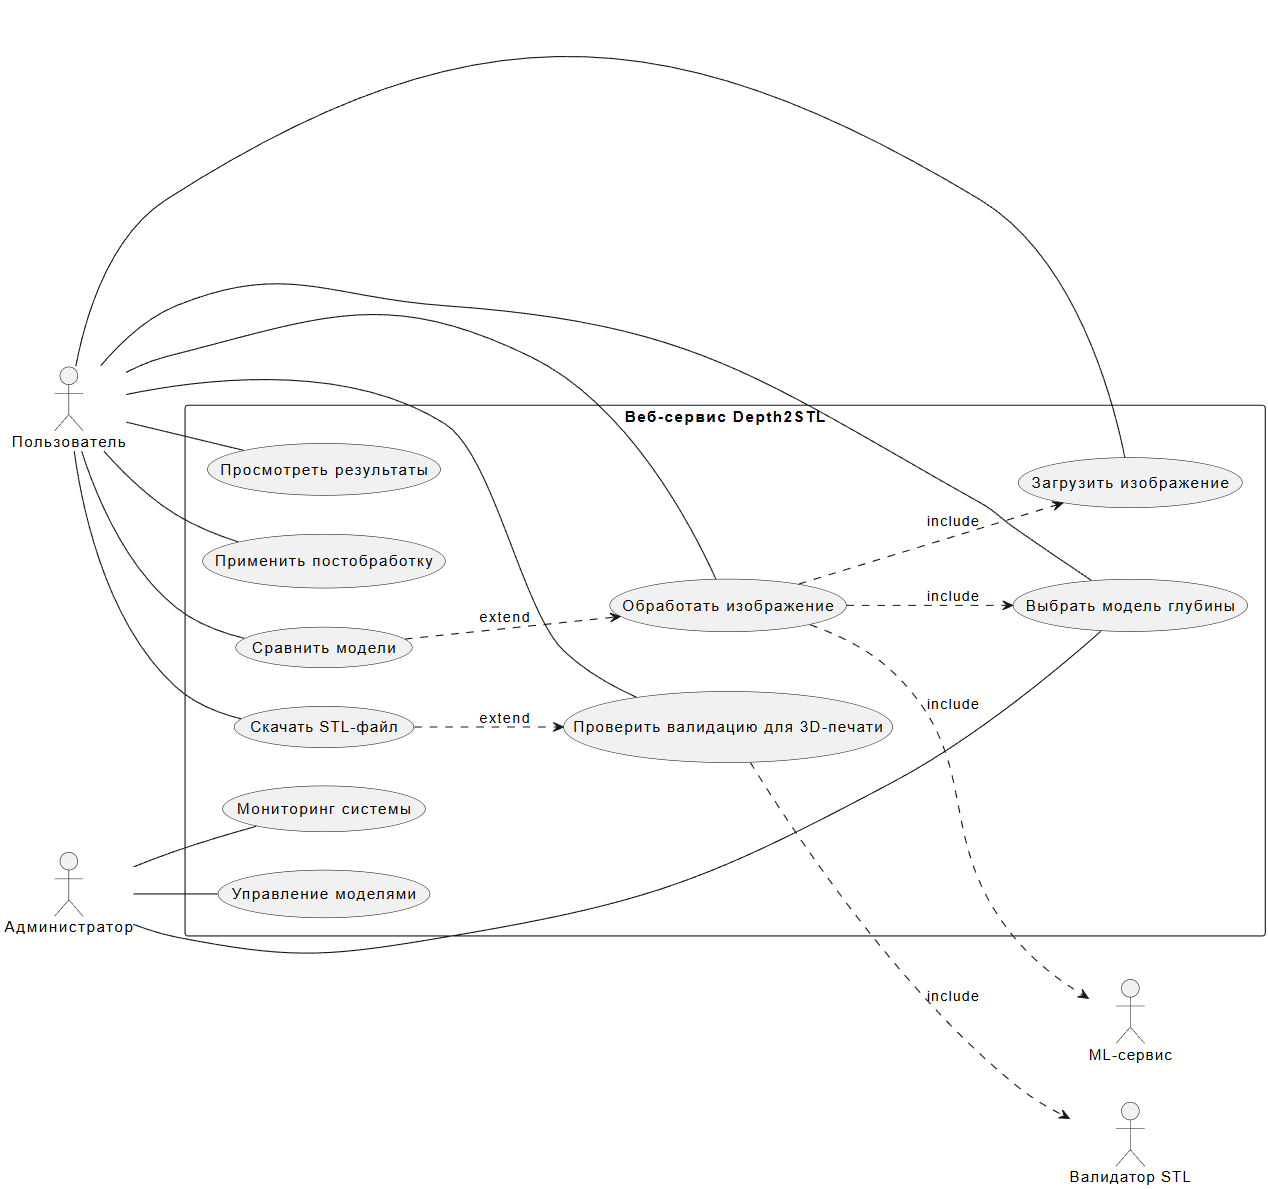

### 1.3. Описание вариантов использования

| Действие | Вариант использования | Описание | Приоритет |
|----|----------------------|----------|-----------|
| UC-001 | Загрузить изображение | Пользователь загружает JPG/PNG изображение (до 10 МБ) через drag&drop или выбор файла для последующей обработки | Критический |
| UC-002 | Выбрать модель глубины | Пользователь выбирает одну из доступных моделей (MiDaS, DepthAnything, NeRF, Unet) для обработки изображения | Критический |
| UC-003 | Обработать изображение | Система выполняет инференс выбранной модели для генерации карты глубины и преобразует её в 3D-mesh | Критический |
| UC-004 | Просмотреть результаты | Пользователь просматривает карту глубины и интерактивный 3D-вьюер mesh с возможностью вращения и масштабирования | Высокий |
| UC-005 | Применить постобработку | Пользователь применяет фильтры (сглаживание, decimation) для улучшения качества mesh перед экспортом | Высокий |
| UC-006 | Проверить валидацию для 3D-печати | Система автоматически проверяет mesh на manifold, толщину стенок и другие требования FDM/SLA печати | Высокий |
| UC-007 | Скачать STL-файл | Пользователь экспортирует готовую модель в формате STL для использования в слайсерах и 3D-принтерах | Критический |
| UC-009 | Управление моделями | Администратор добавляет новые модели глубины, настраивает параметры инференса и мониторит использование | Средний |
| UC-010 | Мониторинг системы | Администратор отслеживает производительность, логи ошибок и использование GPU-ресурсов | Средний |

### 1.4. Отношения между вариантами использования

```
• Обработать изображение INCLUDE Загрузить изображение
• Обработать изображение INCLUDE Выбрать модель глубины
• Обработать изображение INCLUDE [ML-сервис].Выполнить инференс
• Проверить валидацию INCLUDE [Валидатор STL].Проверить геометрию
• Сравнить модели EXTEND Обработать изображение (при выборе ≥2 моделей)
• Скачать STL EXTEND Проверить валидацию (только если валидация прошла)

```

---

## 2. ДИАГРАММА КЛАССОВ (CLASS DIAGRAM)

### 2.1. Основные классы системы



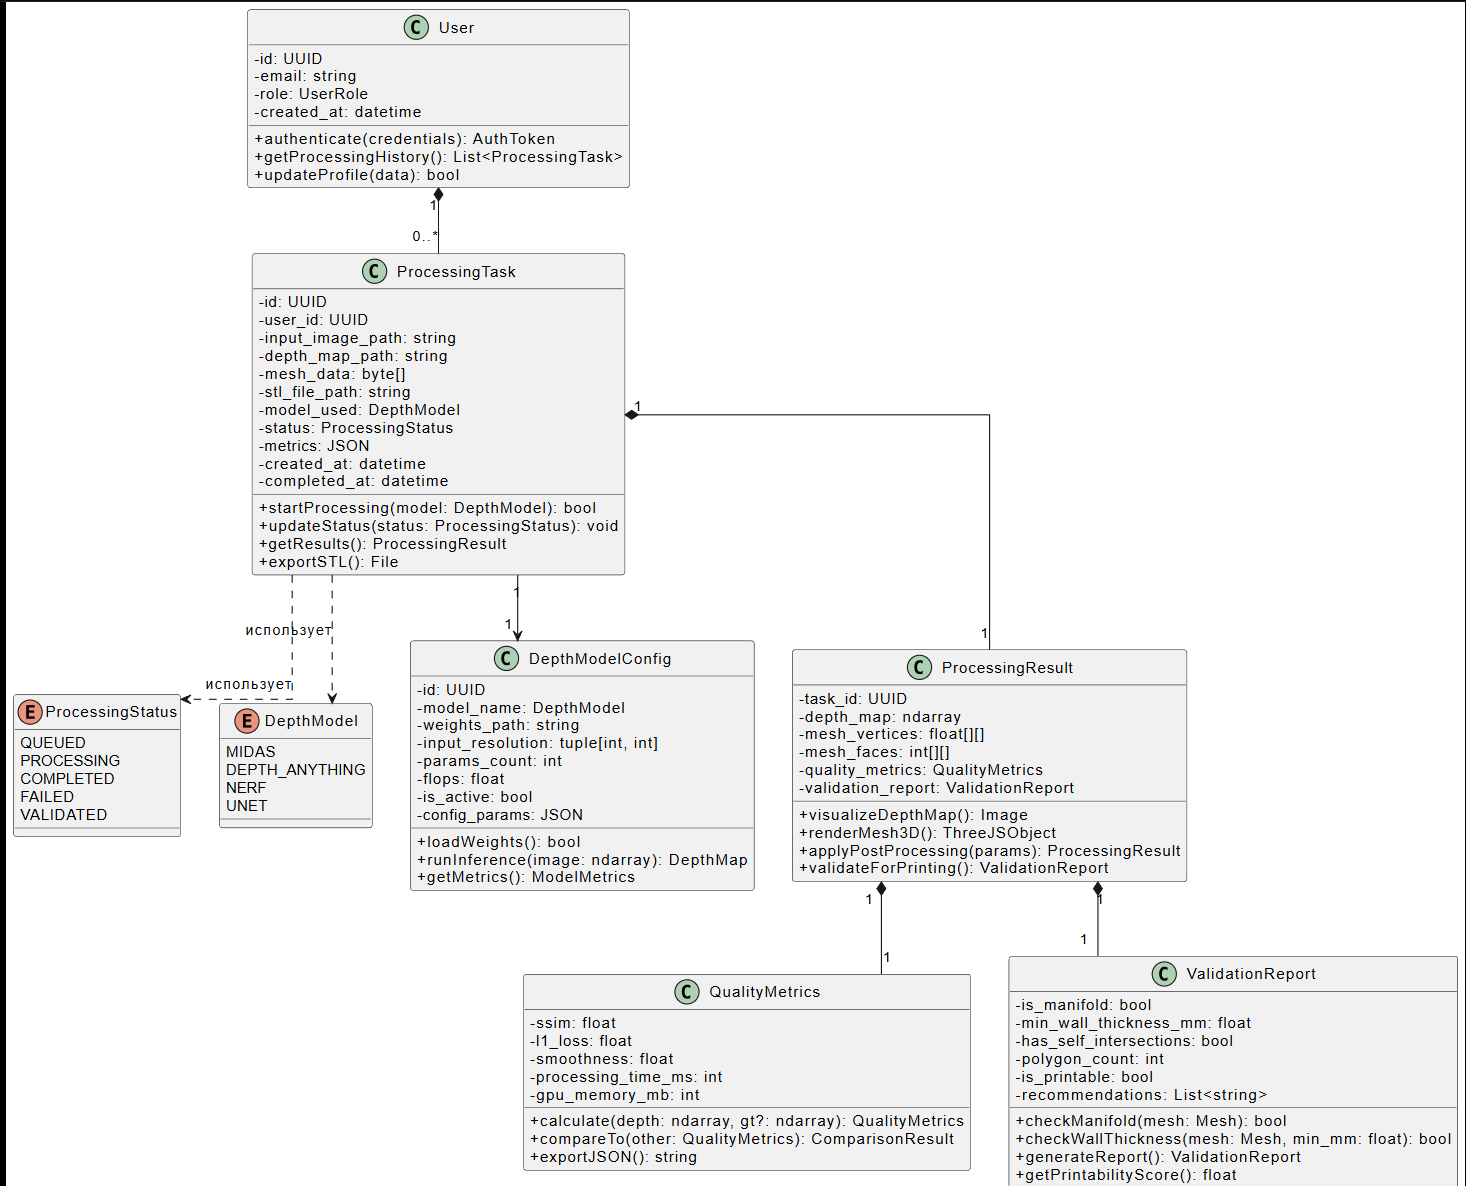

### 2.2. Отношения между классами

| Отношение | Классы | Тип | Описание |
|-----------|--------|-----|----------|
| 1 | User → ProcessingTask | Агрегация (1..*) | Пользователь может иметь множество задач обработки |
| 2 | ProcessingTask → DepthModelConfig | Ассоциация (1..1) | Каждая задача использует одну конфигурацию модели |
| 3 | ProcessingTask → ProcessingResult | Композиция (1..1) | Результат не существует без задачи обработки |
| 4 | ProcessingResult → QualityMetrics | Композиция (1..1) | Метрики являются частью результата |
| 5 | ProcessingResult → ValidationReport | Композиция (1..1) | Отчет валидации является частью результата |
| 6 | DepthModelConfig → ProcessingStatus | Зависимость | Конфигурация влияет на статус обработки |

---

## 3. ДИАГРАММА КОМПОНЕНТОВ (COMPONENT DIAGRAM)

### 3.1. Архитектура системы по уровням


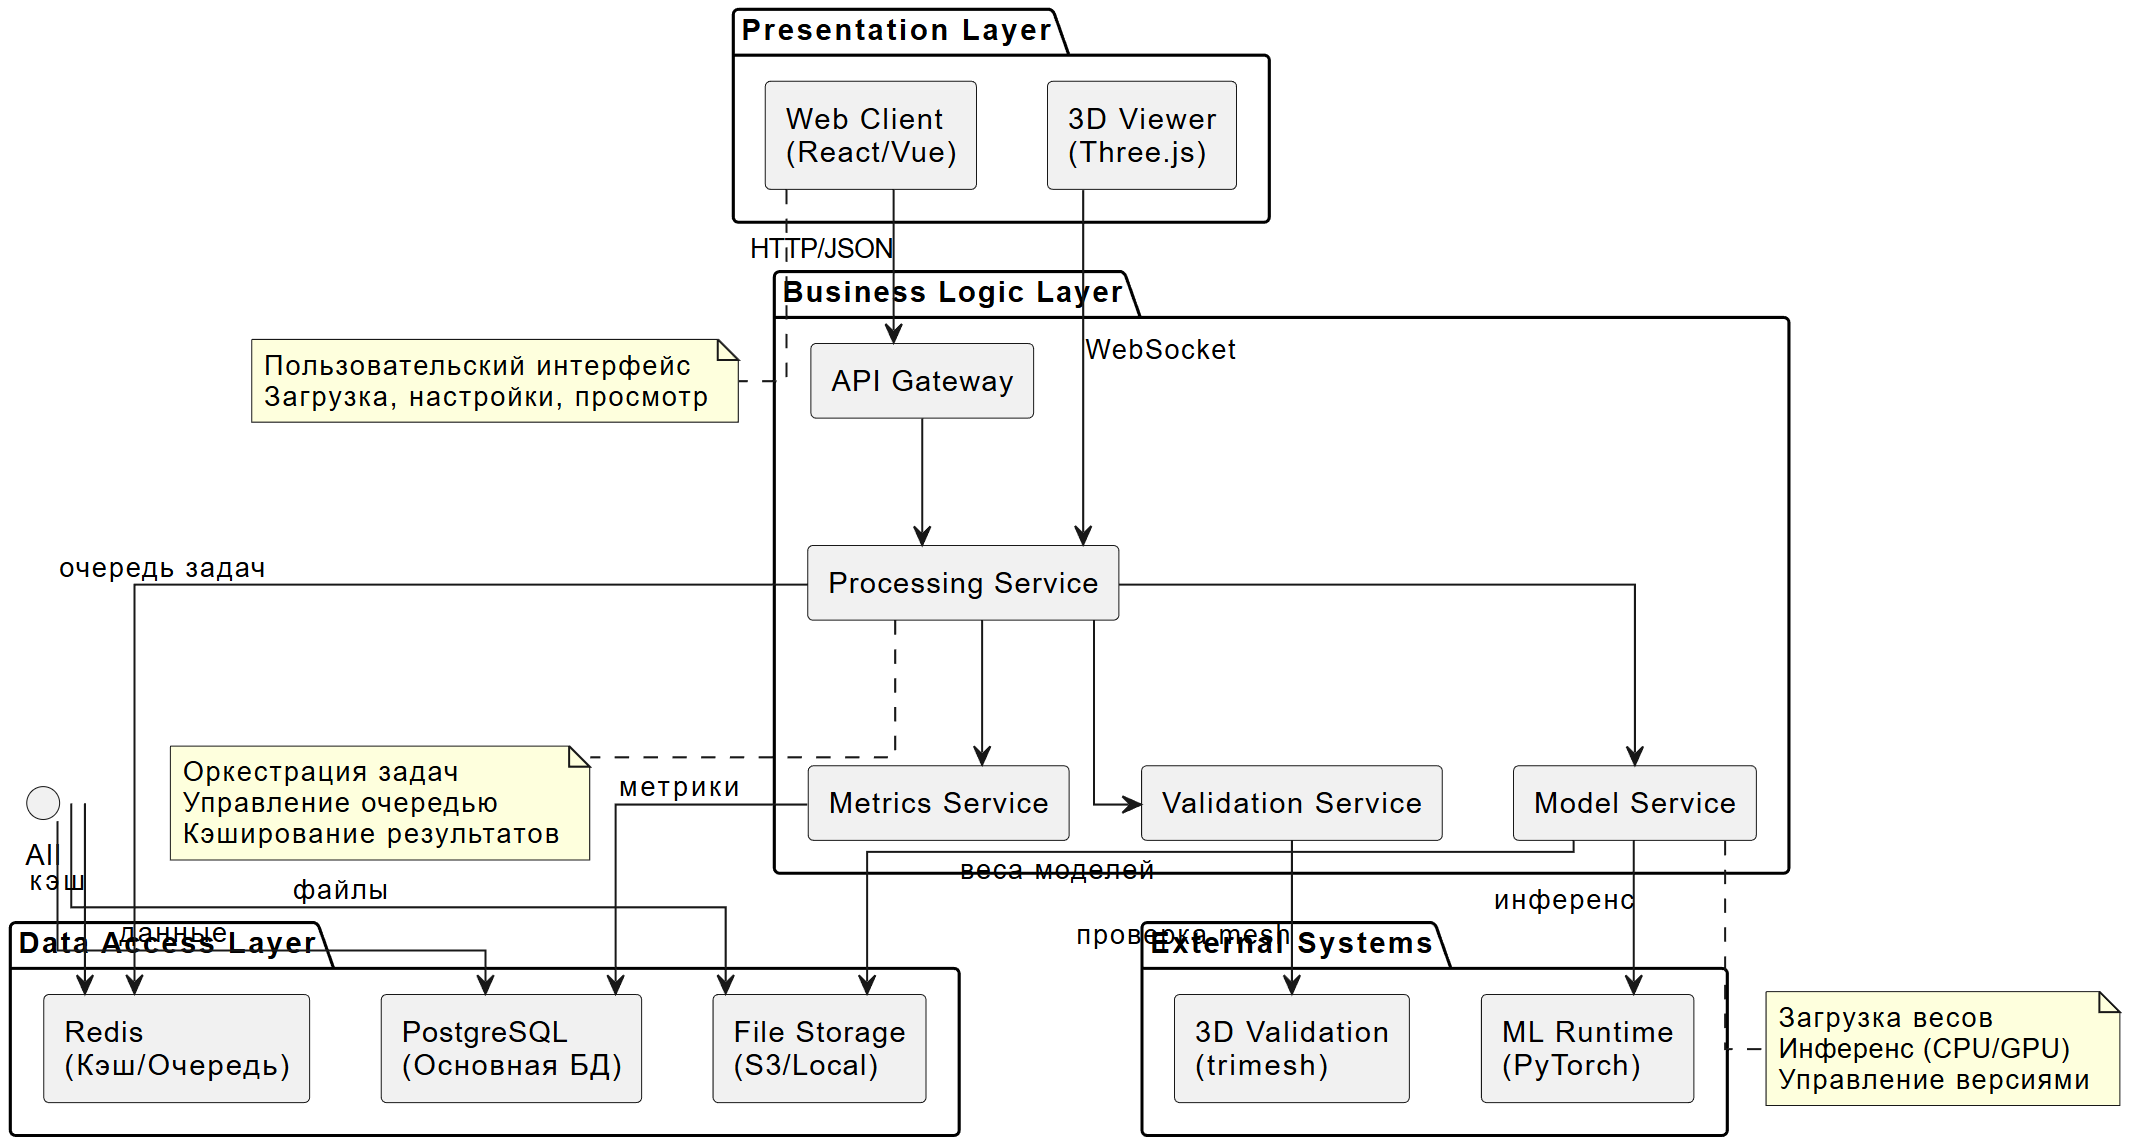

### 3.2. Описание компонентов и интерфейсов

| Компонент | Уровень | Назначение | Интерфейсы | Зависимости |
|-----------|---------|------------|------------|-------------|
| **Web Client** | Presentation | Пользовательский интерфейс для загрузки, настройки и просмотра результатов | `IUserInterface` (user actions) | API Gateway (HTTP) |
| **3D Viewer** | Presentation | Интерактивная визуализация 3D-меша в браузере | `I3DRenderer` (render, rotate, zoom) | Processing Service (WebSocket) |
| **API Gateway** | Business | Единая точка входа, аутентификация, маршрутизация | `IAuthMiddleware`, `IRateLimiter` | All backend services |
| **Processing Service** | Business | Оркестрация задач обработки, управление очередью | `IProcessingService` | Model Service, Validation Service, Redis |
| **Model Service** | Business | Загрузка весов, выполнение инференса моделей глубины | `IModelService` | PyTorch, File Storage |
| **Validation Service** | Business | Проверка mesh на соответствие требованиям 3D-печати | `IValidator` | trimesh, numpy |
| **Metrics Service** | Business | Расчет и сравнение метрик качества (SSIM, L1, FLOPs) | `IMetricsService` | numpy, scikit-image |
| **PostgreSQL** | Data | Хранение структурированных данных (пользователи, задачи, метрики) | `IRepository` (CRUD) | - |
| **Redis** | Data | Кэширование, очередь задач (Celery), сессии | `ICache`, `IQueue` | - |
| **File Storage** | Data | Хранение бинарных файлов (изображения, STL, depth maps) | `IFileStorage` (upload, download) | S3-compatible API |
| **ML Runtime** | External | Выполнение инференса нейросетевых моделей | `IInferenceEngine` | PyTorch, CUDA |
| **3D Validation** | External | Библиотеки для работы с 3D-геометрией | `IMeshValidator` | trimesh, numpy-stl |

### 3.3. Зависимости между компонентами

```
Web Client ──HTTP/JSON──► API Gateway
3D Viewer ──WebSocket──► Processing Service

API Gateway ──► Processing Service
              ──► Model Service  
              ──► Validation Service

Processing Service ──► Redis (queue)
                    ──► Model Service (infer)
                    ──► Validation Service (validate)
                    ──► Metrics Service (calculate)

Model Service ──► File Storage (load weights)
               ──► ML Runtime (PyTorch infer)

Validation Service ──► 3D Validation (trimesh)
                    ──► File Storage (load mesh)

All Services ──► PostgreSQL (read/write data)
              ──► File Storage (save results)
              ──► Redis (cache, sessions)
```

---

## 4. ДОПОЛНИТЕЛЬНАЯ ДИАГРАММА: ДИАГРАММА ПОСЛЕДОВАТЕЛЬНОСТИ (SEQUENCE DIAGRAM)

### 4.1. ДИАГРАММА ПОСЛЕДОВАТЕЛЬНОСТИ





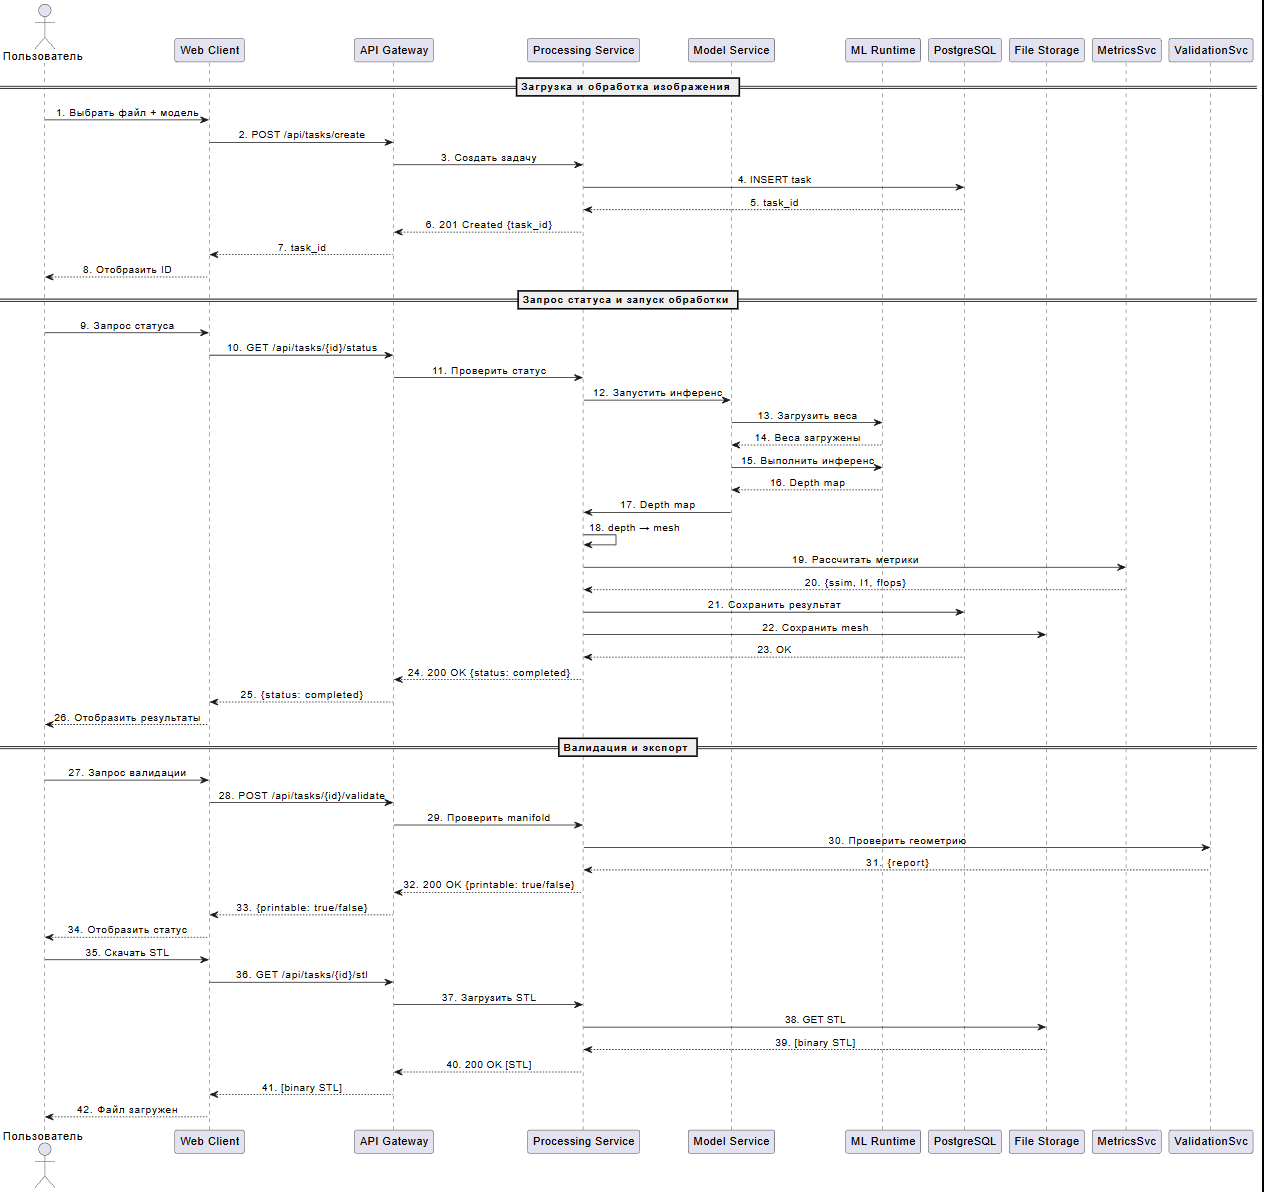

### 4.2 Диаграмма состояний

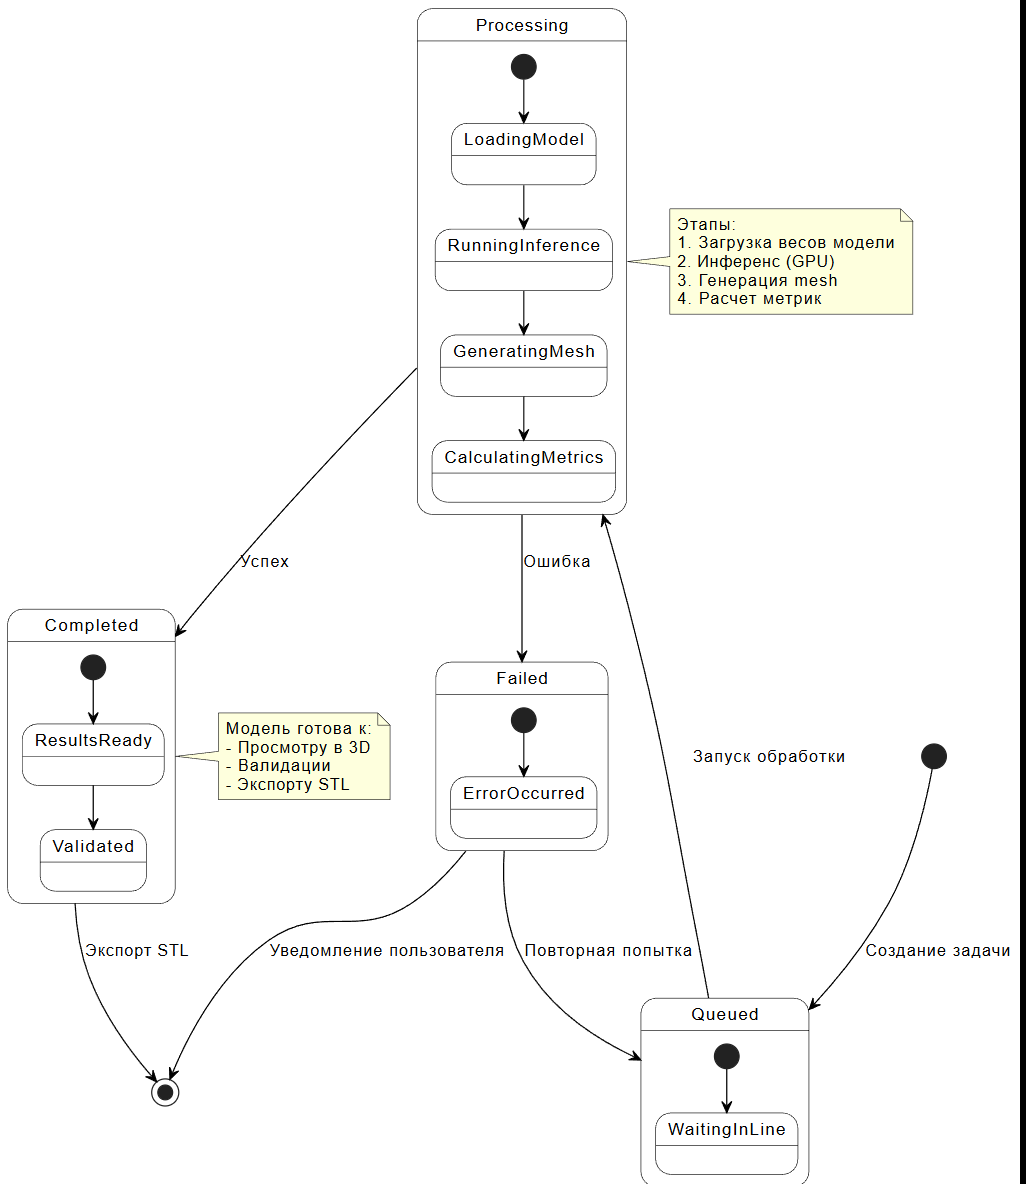

### 4.3 Диаграмма развертывания
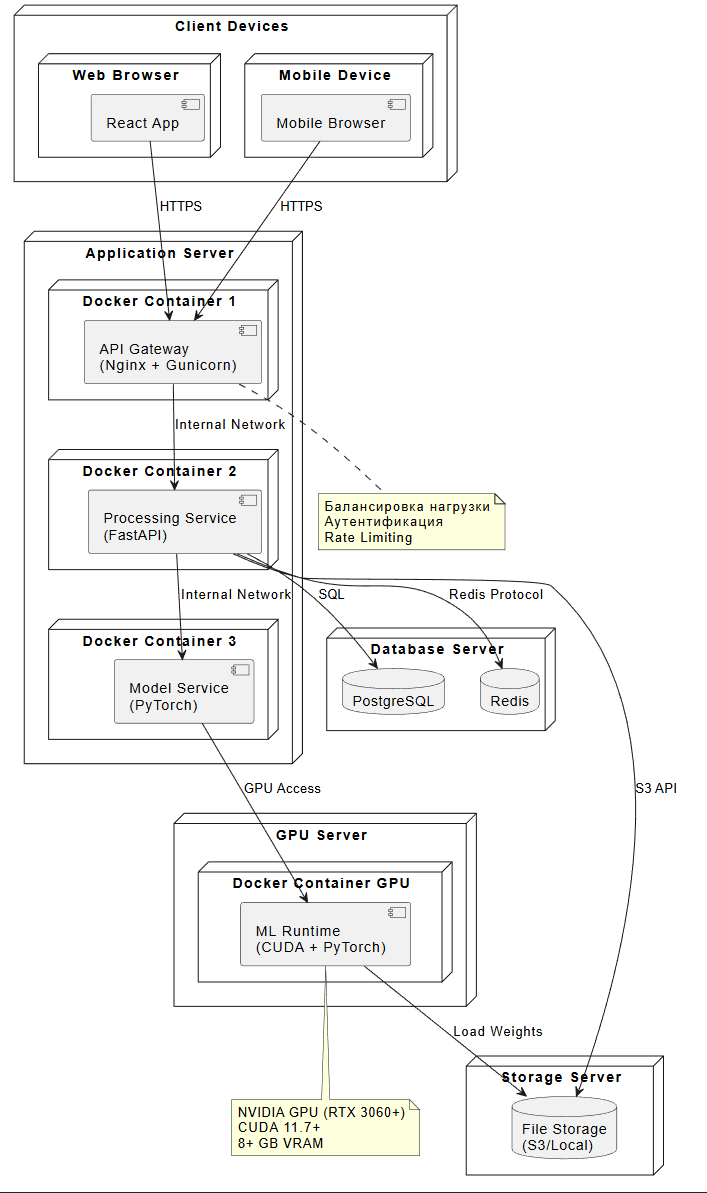

### 4.3. Временные характеристики сценариев

| Этап | Ожидаемое время | Компонент | Примечание |
|------|----------------|-----------|------------|
| Загрузка изображения | 100-500 мс | Web Client → API | Зависит от размера файла |
| Создание задачи в БД | 10-50 мс | Processing Service | PostgreSQL INSERT |
| Инференс модели (GPU) | 2-10 сек | Model Service | Зависит от модели и разрешения |
| Преобразование depth→mesh | 100-500 мс | Processing Service | numpy + trimesh операции |
| Расчет метрик | 50-200 мс | Metrics Service | SSIM, L1 на numpy arrays |
| Валидация STL | 100-300 мс | Validation Service | Проверка manifold, толщины |
| Экспорт STL | 50-150 мс | Processing Service | Бинарный STL генерация |
| **Итого (онлайн)** | **3-12 сек** | - | Для изображения 1024×1024 |

---

## 5. ОБОСНОВАНИЕ ВЫБРАННОЙ АРХИТЕКТУРЫ

### 5.1. Обоснование структуры компонентов

Выбранная многоуровневая архитектура (Presentation → Business Logic → Data Access) обеспечивает следующие преимущества для проекта:

**Модульность и слабая связанность:** Разделение на независимые сервисы (Processing, Model, Validation, Metrics) позволяет разрабатывать, тестировать и масштабировать компоненты отдельно. Например, при добавлении новой модели глубины (например, DPT) достаточно обновить только Model Service, не затрагивая остальную систему.

**Масштабируемость:** Использование Redis для очереди задач (через Celery) позволяет горизонтально масштабировать обработку: при росте нагрузки можно добавить дополнительные worker-инстансы Model Service без изменения кода. API Gateway обеспечивает балансировку запросов между инстансами.

**Изоляция ресурсоемких операций:** ML-инференс вынесен в отдельный компонент (ML Runtime), что позволяет:
- Запускать инференс в изолированных Docker-контейнерах с доступом к GPU
- Применять resource limits (CPU, RAM, GPU memory) для предотвращения исчерпания ресурсов
- Легко заменять backend инференса (PyTorch → ONNX Runtime) без изменения бизнес-логики

### 5.2. Обоснование выбора технологий

| Компонент | Технология | Обоснование выбора |
|-----------|-----------|-------------------|
| Backend | Python + FastAPI | Нативная поддержка async, автоматическая документация OpenAPI, отличная интеграция с PyTorch |
| ML Framework | PyTorch 2.0+ | Поддержка большинства state-of-the-art моделей глубины (MiDaS, DepthAnything), динамические графы для отладки |
| 3D Processing | trimesh + numpy | Легковесные библиотеки для работы с mesh, поддержка STL/OBJ, проверка manifold |
| Frontend | React + Three.js | Богатая экосистема компонентов, отличная поддержка WebGL для интерактивного 3D-вьюера |
| Database | PostgreSQL + Redis | PostgreSQL для надежного хранения структурированных данных, Redis для кэширования и очереди задач |
| Deployment | Docker + Docker Compose | Воспроизводимость окружения, простота развертывания, изоляция зависимостей |

### 5.3. Связь с требованиями SRS

Диаграммы напрямую отражают функциональные и нефункциональные требования из спецификации:

- **ФТ-002, ФТ-003** (выбор и сравнение моделей) → Класс `DepthModelConfig` и компонент `Model Service` с интерфейсом `IModelService`
- **ФТ-005, ФТ-006** (генерация depth и mesh) → Класс `ProcessingResult` с методами `visualizeDepthMap()` и `renderMesh3D()`
- **ФТ-007** (экспорт STL) → Метод `ProcessingTask.exportSTL()` и зависимость от компонента File Storage
- **ФТ-008, ФТ-009** (постобработка и валидация) → Классы `QualityMetrics` и `ValidationReport`, компонент `Validation Service`
- **НФТ-П-001** (время обработки ≤10 сек) → Диаграмма последовательности с временными характеристиками каждого этапа
- **НФТ-Б-002** (изоляция ML-контейнеров) → Компонент `ML Runtime` в отдельном Docker-контейнере с resource limits

---

## 6. ПРИЛОЖЕНИЯ

### Приложение А. Глоссарий терминов UML

| Термин | Определение | Пример в проекте |
|--------|-------------|------------------|
| **Актор** | Внешний субъект, взаимодействующий с системой | Пользователь, ML-сервис |
| **Вариант использования** | Единица функциональности, видимая пользователю | "Скачать STL-файл" |
| **Класс** | Шаблон для создания объектов с атрибутами и методами | `ProcessingTask`, `QualityMetrics` |
| **Компонент** | Модуль системы с четко определенными интерфейсами | `Model Service`, `Validation Service` |
| **Интерфейс** | Контракт, определяющий доступные операции | `IModelService.infer(image)` |
| **Ассоциация** | Связь между классами, означающая "знает о" | `User` знает о `ProcessingTask` |
| **Композиция** | Сильная связь "часть-целое", жизненный цикл зависим | `ProcessingResult` содержит `ValidationReport` |
| **Агрегация** | Слабая связь "часть-целое", жизненный цикл независим | `User` агрегирует `ProcessingTask` |